In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

# def

In [4]:
import json
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import matplotlib.pyplot as plt

DATA_PATH = "/content/drive/MyDrive/Colab/labels_GTZAN.json"

def load_data(data_path):

    with open(data_path, "r") as fp:
        data = json.load(fp)

    # convert lists to numpy arrays
    X = np.array(data["mfcc"])
    y = np.array(data["labels"])

    return  X, y

def plot_history(history):
    
    fig, axs = plt.subplots(2)

    # create accuracy sublpot
    axs[0].plot(history.history["accuracy"], label="train accuracy")
    axs[0].plot(history.history["val_accuracy"], label="test accuracy")
    axs[0].set_ylabel("Accuracy")
    axs[0].set_ylim([0, 1])
    axs[0].legend(loc="lower right")
    axs[0].set_title("Accuracy eval")

    # create error sublpot
    axs[1].plot(history.history["loss"], label="train error")
    axs[1].plot(history.history["val_loss"], label="test error")
    axs[1].set_ylabel("Error")
    axs[1].set_xlabel("Epoch")
    axs[1].legend(loc="upper right")
    axs[1].set_title("Error eval")

    plt.tight_layout()
    
    plt.show()

def prepare_datasets(test_size, validation_size):
    
    # load data
    X, y = load_data(DATA_PATH)

    # create train, validation and test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, 
                                                                    test_size=validation_size)
    # add an axis to input sets
    X_train = X_train[..., np.newaxis]
    X_validation = X_validation[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    return X_train, X_validation, X_test, y_train, y_validation, y_test

# build model

In [5]:
def build_model(input_shape):

    # build network topology
    model_CNN = keras.Sequential()

    # 1st conv layer
    model_CNN.add(keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model_CNN.add(keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'))
    model_CNN.add(keras.layers.BatchNormalization())

    # 2nd conv layer
    model_CNN.add(keras.layers.Conv2D(32, (3, 3), activation='relu'))
    model_CNN.add(keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'))
    model_CNN.add(keras.layers.BatchNormalization())

    # 3rd conv layer
    model_CNN.add(keras.layers.Conv2D(32, (2, 2), activation='relu'))
    model_CNN.add(keras.layers.MaxPooling2D((2, 2), strides=(2, 2), padding='same'))
    model_CNN.add(keras.layers.BatchNormalization())

    # flatten output and feed it into dense layer
    model_CNN.add(keras.layers.Flatten())
    model_CNN.add(keras.layers.Dense(64, activation='relu'))
    model_CNN.add(keras.layers.Dropout(0.3))

    # output layer
    model_CNN.add(keras.layers.Dense(10, activation='softmax'))

    return model_CNN

# train

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 11, 32)       320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 6, 32)        0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 64, 6, 32)        128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 62, 4, 32)         9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 31, 2, 32)        0         
 2D)                                                             
                                                        

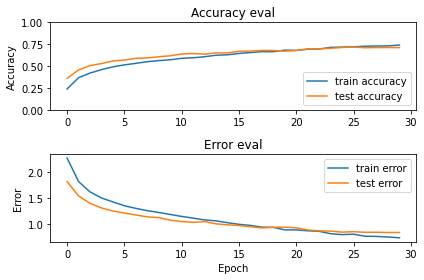

79/79 - 1s - loss: 0.8124 - accuracy: 0.7123 - 1s/epoch - 13ms/step
Test accuracy: 0.7122849225997925


In [6]:
if __name__ == "__main__":

    # train, validation, test splits
    # prepare_datasets(測試,驗證)
    X_train, X_validation, X_test, y_train, y_validation, y_test = prepare_datasets(0.25, 0.2)

    # create network
    input_shape = (X_train.shape[1], X_train.shape[2], 1)
    model_CNN = build_model(input_shape)

    # compile model
    optimiser = keras.optimizers.Adam(learning_rate=0.0001)
    model_CNN.compile(optimizer=optimiser,
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

    model_CNN.summary()

    # train model
    history = model_CNN.fit(X_train, y_train, validation_data=(X_validation, y_validation), 
                            batch_size=32, epochs=30)


    # save model
    model_CNN.save('Music_Gnere_Classifier_GTZAN.h5')
    model_CNN.save_weights('Music_Gnere_Classifier_GTZAN_weight.h5')

    # plot accuracy/error for training and validation
    plot_history(history)

    # evaluate model on test set
    test_loss, test_acc = model_CNN.evaluate(X_test, y_test, verbose=2)
    print('Test accuracy:', test_acc)

# confusion matrix

In [7]:
from sklearn.metrics import classification_report

import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    # print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

Normalized confusion matrix


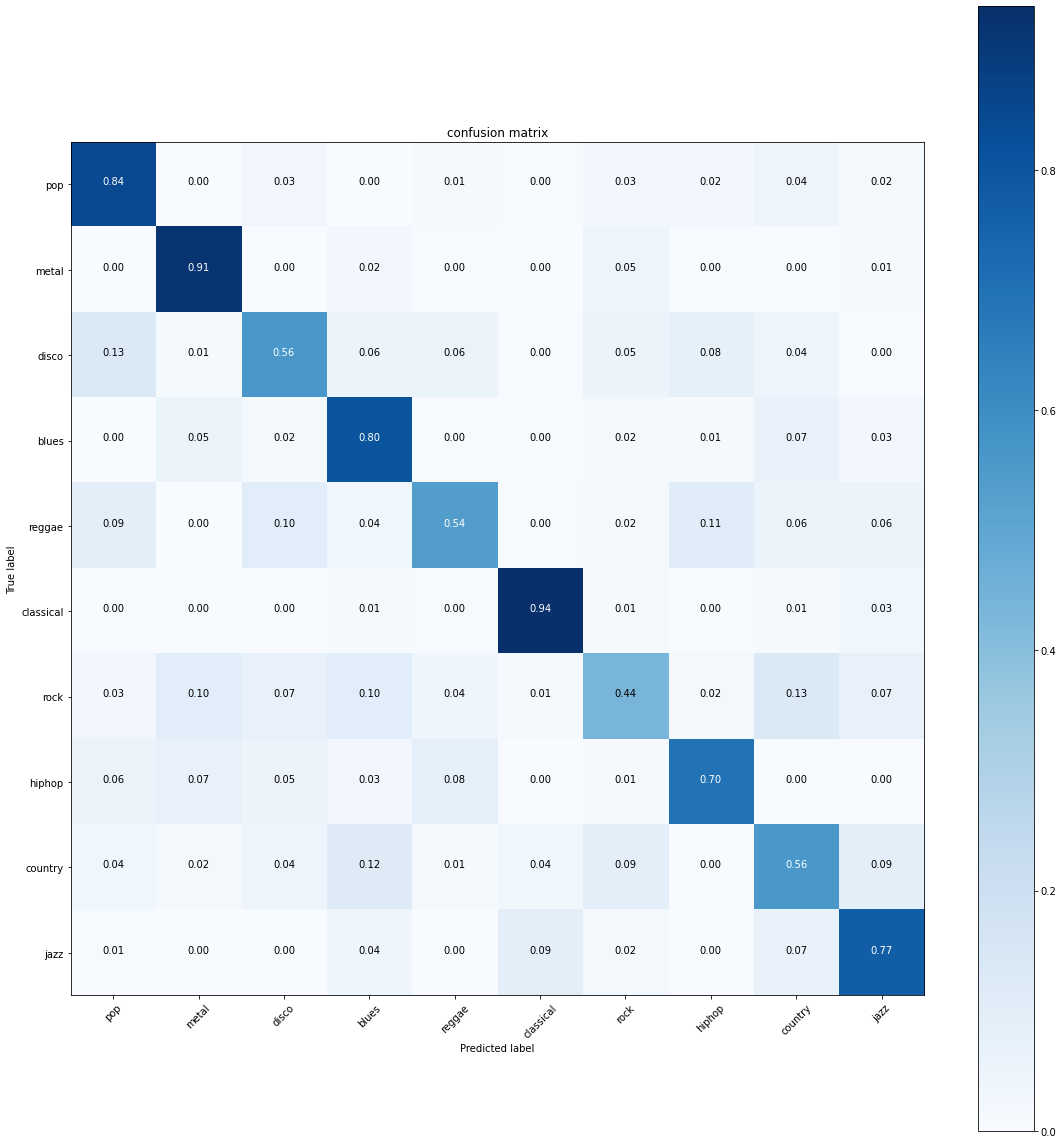

In [8]:
target_names = ['pop','metal','disco','blues','reggae','classical','rock','hiphop','country','jazz']

y_predict = model_CNN.predict(X_test, batch_size=None, verbose=0, steps=None)
y_pred = np.argmax(y_predict, axis=1)
y_true = y_test

plt.figure(figsize=(16,16))
cnf_matrix = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cnf_matrix, classes=target_names, normalize=True, title='confusion matrix')

plt.show()

# Predict a Sample From model_CNN

In [9]:
def predict(model, X, y):
    
    # mapping labels to targets
    target = ['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']
    
    # add a dimension to input data for sample - model.predict() expects a 4d array in this case
    X = X[np.newaxis]

    # perform prediction
    prediction = model_CNN.predict(X)

    # get index with max value
    predicted_index = np.argmax(prediction, axis=1)[0]
    
    print("音樂類型為: {}\n預測結果為: {}".format(target[y], target[predicted_index]))
    
# pick a sample to predict from the test set
# from 0~2498
a = 456
X_to_predict = X_test[a]
y_to_predict = y_test[a]

# predict sample
predict(model_CNN, X_to_predict, y_to_predict)

音樂類型為: pop
預測結果為: pop


# Model_DNN

In [10]:
# if __name__ == "__main__":

#     # load data
#     X, y = load_data(DATA_PATH)

#     # create train/test split
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

#     # build network topology
#     model = keras.Sequential([

#         # input layer
#         keras.layers.Flatten(input_shape=(X.shape[1], X.shape[2])),

#         # 1st dense layer
#         keras.layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
#         keras.layers.Dropout(0.3),

#         # 2nd dense layer
#         keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
#         keras.layers.Dropout(0.3),

#         # 3rd dense layer
#         keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
#         keras.layers.Dropout(0.3),

#         # output layer
#         keras.layers.Dense(10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.001))
#     ])

#     # compile model
#     optimiser = keras.optimizers.Adam(learning_rate=0.0001)
#     model.compile(optimizer=optimiser,
#                   loss='sparse_categorical_crossentropy',
#                   metrics=['accuracy'])

#     model.summary()

#     # train model
#     history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=32, epochs=50)
    
#     # plot accuracy and error as a function of the epochs
#     plot_history(history)

# Model_RNN (LSTM)

In [11]:
# def prepare_datasets(test_size, validation_size):
#     """
#     Loads data and splits it into train, validation and test sets.
#     :param test_size (float): Value in [0, 1] indicating percentage of data set to 
#      allocate to test split
#     :param validation_size (float): Value in [0, 1] indicating percentage of train set to 
#      allocate to validation split
#     :return X_train (ndarray): Input training set
#     :return X_validation (ndarray): Input validation set
#     :return X_test (ndarray): Input test set
#     :return y_train (ndarray): Target training set
#     :return y_validation (ndarray): Target validation set
#     :return y_test (ndarray): Target test set
#     """

#     # load data
#     X, y = load_data(DATA_PATH)

#     # create train, validation and test split
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
#     X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, 
#                                                                     test_size=validation_size)

#     return X_train, X_validation, X_test, y_train, y_validation, y_test


# def build_model(input_shape):
#     """Generates RNN-LSTM model
#     :param input_shape (tuple): Shape of input set
#     :return model: RNN-LSTM model
#     """

#     # build network topology
#     model_RNN = keras.Sequential()

#     # 2 LSTM layers
#     model_RNN.add(keras.layers.LSTM(64, input_shape=input_shape, return_sequences=True))
#     model_RNN.add(keras.layers.LSTM(64))

#     # dense layer
#     model_RNN.add(keras.layers.Dense(64, activation='relu'))
#     model_RNN.add(keras.layers.Dropout(0.3))

#     # output layer
#     model_RNN.add(keras.layers.Dense(10, activation='softmax'))

#     return model


# if __name__ == "__main__":

#     # get train, validation, test splits
#     X_train, X_validation, X_test, y_train, y_validation, y_test = prepare_datasets(0.25, 0.2)

#     # create network
#     input_shape = (X_train.shape[1], X_train.shape[2]) # 130, 13
#     model_RNN = build_model(input_shape)

#     # compile model
#     optimiser = keras.optimizers.Adam(learning_rate=0.0001)
#     model_RNN.compile(optimizer=optimiser,
#                   loss='sparse_categorical_crossentropy',
#                   metrics=['accuracy'])

#     model_RNN.summary()

#     # train model
#     history = model_RNN.fit(X_train, y_train, validation_data=(X_validation, y_validation), 
#                             batch_size=32, epochs=30)

#     # plot accuracy/error for training and validation
#     plot_history(history)

#     # evaluate model on test set
#     test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
#     print('\nTest accuracy:', test_acc)